## Support tickets — dataloader test

This notebook checks that **`supportDataset`** and **`DataLoader`** work for fine-tuning on support-ticket text.

- **CSV**: Each row has a ticket `text` and a string `label` (e.g. `shipping_delay`). The dataset maps those strings to integer class ids `0 … num_classes-1`.
- **Tokenizer**: GPT-2 byte-pair encoding via `tiktoken`; every example is padded or truncated to a fixed length (`max_length=None` uses the longest sequence in the split).
- **Sampling**: `sample_from_dataset` shows individual examples; `peek_dataloader_batch` shows one full batch after stacking (default PyTorch collate).

The **next cell** summarizes what each printed line means. **After that**, run the code cells to load the data and print samples.

**End of notebook:** fine-tuning sweep **findings** from `stats_output/` (tables, plots, plain-language interpretation).

### What you should see in the output

| Print | Meaning |
|--------|---------|
| `7` | Number of distinct ticket categories (`num_classes`). |
| `torch.Size([12])`, `4`, `shipping_delay` | One example: token ids length 12 (padded length for this split), class id `4`, and the original label name. Three such lines = three random rows. |
| `torch.Size([8, 12])`, `torch.Size([8])` | One batch: **8** sequences of length **12**, and **8** integer labels—this is the tensor shape the training loop will consume. |

In [10]:
import tiktoken
from torch.utils.data import DataLoader
from gpt_class_finetune import SupportDataset, sample_from_dataset, peek_dataloader_batch

# Initialize tokenizer
tokenizer = tiktoken.get_encoding('gpt2')

# Initialize dataset
train_dataset = SupportDataset(
    csv_file='data/support_tickets_train.csv',
    tokenizer=tokenizer,
    max_length=None,
    balance_dataset=True
)

print(train_dataset.num_classes)

# Create DataLoader
num_workers = 0
batch_size = 8

train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, drop_last=False
)

rows = sample_from_dataset(train_dataset, k=3, seed=43)
for input_ids, y in rows:
    print(input_ids.shape, y.item(), train_dataset.id_to_label[y.item()])

inputs, labels = peek_dataloader_batch(train_loader)
print(inputs.shape, labels.shape)


7
torch.Size([12]) 3 password_reset
torch.Size([12]) 2 cancel_subscription
torch.Size([12]) 5 technical_bug
torch.Size([8, 12]) torch.Size([8])


In [11]:
import pandas as pd

df = pd.read_csv('data/support_tickets_train.csv')
vc = df['label'].value_counts()
spread_pct = (vc.max() / vc.min() - 1) * 100
print(f'Before balancing: Max class count is {spread_pct:.1f}% above the min class count')
print(df['label'].value_counts())

print('\n')

balanced_df = train_dataset._create_balanced_dataset()
print('After balancing:')
print(balanced_df['label'].value_counts())


Before balancing: Max class count is 15.2% above the min class count
label
billing_refund         167
account_locked         157
technical_bug          156
cancel_subscription    155
update_payment         153
password_reset         145
shipping_delay         145
Name: count, dtype: int64


After balancing:
label
billing_refund         145
account_locked         145
technical_bug          145
cancel_subscription    145
update_payment         145
password_reset         145
shipping_delay         145
Name: count, dtype: int64


## Fine-tuning experiment findings (`stats_output/`)

This section summarizes hyperparameter sweeps for **GPT-2 class fine-tuning** on the support-ticket data.  
Each row in `training-data.csv` is one run (hyperparameters + seed). Outputs in `stats_output/` aggregate **mean validation and test accuracy** over 5 seeds per setting, and (in `val_vs_test_by_sweep_level.csv`) the **gap** = test − val (how much hold-out test differs from validation after training).

### What stands out

1. **Learning rate dominates.** At **`lr = 1e-5`**, mean **test accuracy ~0.25** and **val ~0.33** — the model barely fits the task. At **`5e-5`** (reference), **`1e-4`**, and **`0.0001`**, means sit near **~0.997** test accuracy. So there is a **sharp floor**: too small a step size wastes the run; the good settings cluster at a **ceiling** (~100% on this split).

2. **Training long enough matters.** **`epochs = 3`** gives **mean test ~0.96** vs reference **`epochs = 5`** and sweep **`epochs = 8`** near **~0.997**. Fewer epochs = clear underfitting relative to the stronger baseline; val is also lower (~0.90 vs ~0.99).

3. **Batch size, dropout, weight decay, balancing.** In the summary table, **reference** and most alternative levels differ by **tiny amounts** on test (often within noise at this ceiling). **Batch 13** shows slightly lower **val** than batch 3/5 but **test** stays high. **`drop_rate`** 0.05 vs 0.1 and **`weight_decay`** 0.05 vs 0.2 barely move mean test. **`balance_dataset = 0`** vs reference **`1`**: mean **test ~0.997** in both rows in the table — **balancing did not change headline test accuracy** in this run set (validation differs only slightly).

4. **Validation vs test.** For strong configs, **gap** (test − val) is small and positive on average (test slightly above val). For **`lr = 1e-5`**, both metrics collapse; **gap** is negative on average, meaning **val looks worse than test** cannot be interpreted as “good generalization” there—the model is simply not learning.

### Files in `stats_output/`

| File | Role |
|------|------|
| `val_vs_test_by_sweep_level.csv` | Per sweep × level: mean **val**, mean **test**, mean **gap**, **n** |
| `classical_tests.csv` | Optional: ANOVA / paired t summaries from an earlier analysis pipeline (if present) |
| `*.png` | Figures (e.g. mean test vs **lr**, **epochs**, **balanced**) — generated when you run `run_stats.py` |

Run the **next cell** to load the table and show any PNGs in `stats_output/`.

### Summary: `val_vs_test_by_sweep_level.csv`

,sweep,factor_level,val_accuracy_mean,val_accuracy_std,test_accuracy_mean,test_accuracy_std,gap_mean,gap_std,n
0,balance_dataset,0,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
1,batch_size,13,0.984615,0.018842,0.993939,0.005808,0.009324,0.013746,5
2,batch_size,3,1.000000,0.000000,0.997403,0.005808,-0.002597,0.005808,5
3,batch_size,5,0.984000,0.035777,0.997403,0.005808,0.013403,0.029969,5
4,drop_rate,0.05,0.980000,0.027386,0.994805,0.007113,0.014805,0.020273,5
5,drop_rate,0.1,0.990000,0.022361,0.995671,0.006122,0.005671,0.017917,5
6,epochs,3,0.900000,0.063738,0.962771,0.032046,0.062771,0.046555,5
7,epochs,8,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
8,lr,0.0001,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
9,lr,1e-05,0.325000,0.119896,0.252814,0.078258,-0.072186,0.116503,5


### Classical tests (optional)

,test,sweep,contrast,statistic,pvalue,detail
0,paired_ttest_test_accuracy_vs_ref,balance_dataset,level=0 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
1,paired_ttest_gap_vs_ref,balance_dataset,level=0 vs reference (by seed),NaN,NaN,mean_delta_gap=0.000000
2,anova_test_accuracy,batch_size,k=3 levels,0.592593,0.568290,one-way ANOVA
3,anova_gap_test_minus_val,batch_size,k=3 levels,0.925102,0.423010,one-way ANOVA on generalization gap
4,paired_ttest_test_accuracy_vs_ref,batch_size,level=13 vs reference (by seed),-1.632993,0.177808,mean_delta_test=-0.003463
5,paired_ttest_gap_vs_ref,batch_size,level=13 vs reference (by seed),0.922217,0.408606,mean_delta_gap=0.001922
6,paired_ttest_test_accuracy_vs_ref,batch_size,level=3 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
7,paired_ttest_gap_vs_ref,batch_size,level=3 vs reference (by seed),-1.000000,0.373901,mean_delta_gap=-0.010000
8,paired_ttest_test_accuracy_vs_ref,batch_size,level=5 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
9,paired_ttest_gap_vs_ref,batch_size,level=5 vs reference (by seed),1.000000,0.373901,mean_delta_gap=0.006000


_… 26 more rows_

### Figures

**`epoch_vs_mean_test_accuracy.png`**

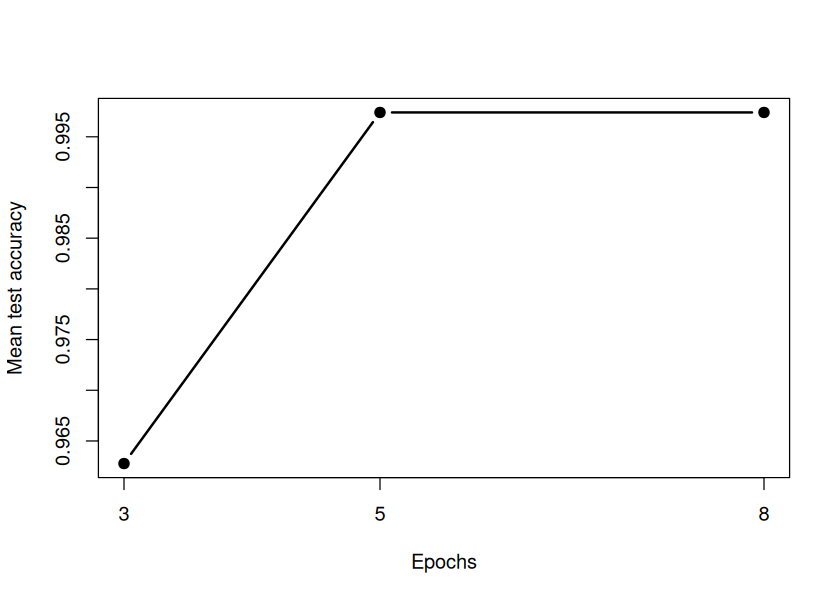

**`mean_test_accuracy_by_balanced.png`**

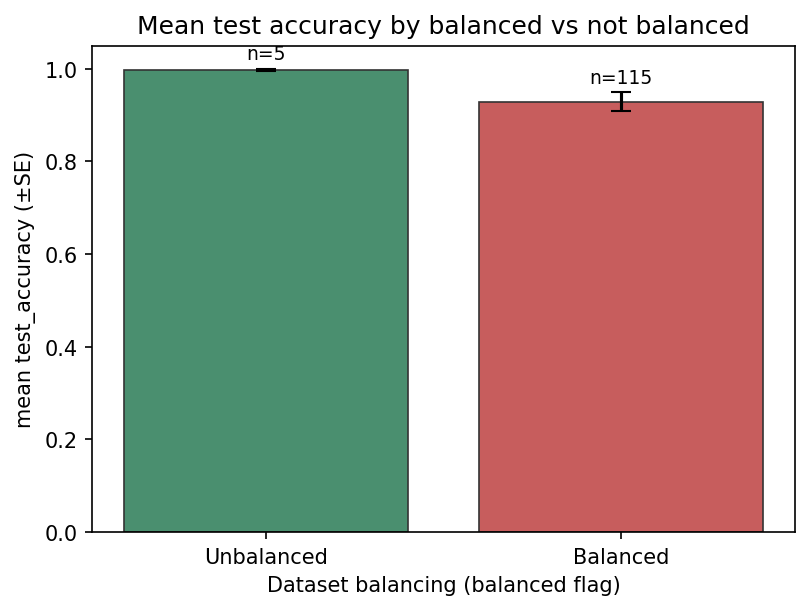

**`mean_val_vs_test_by_condition.png`**

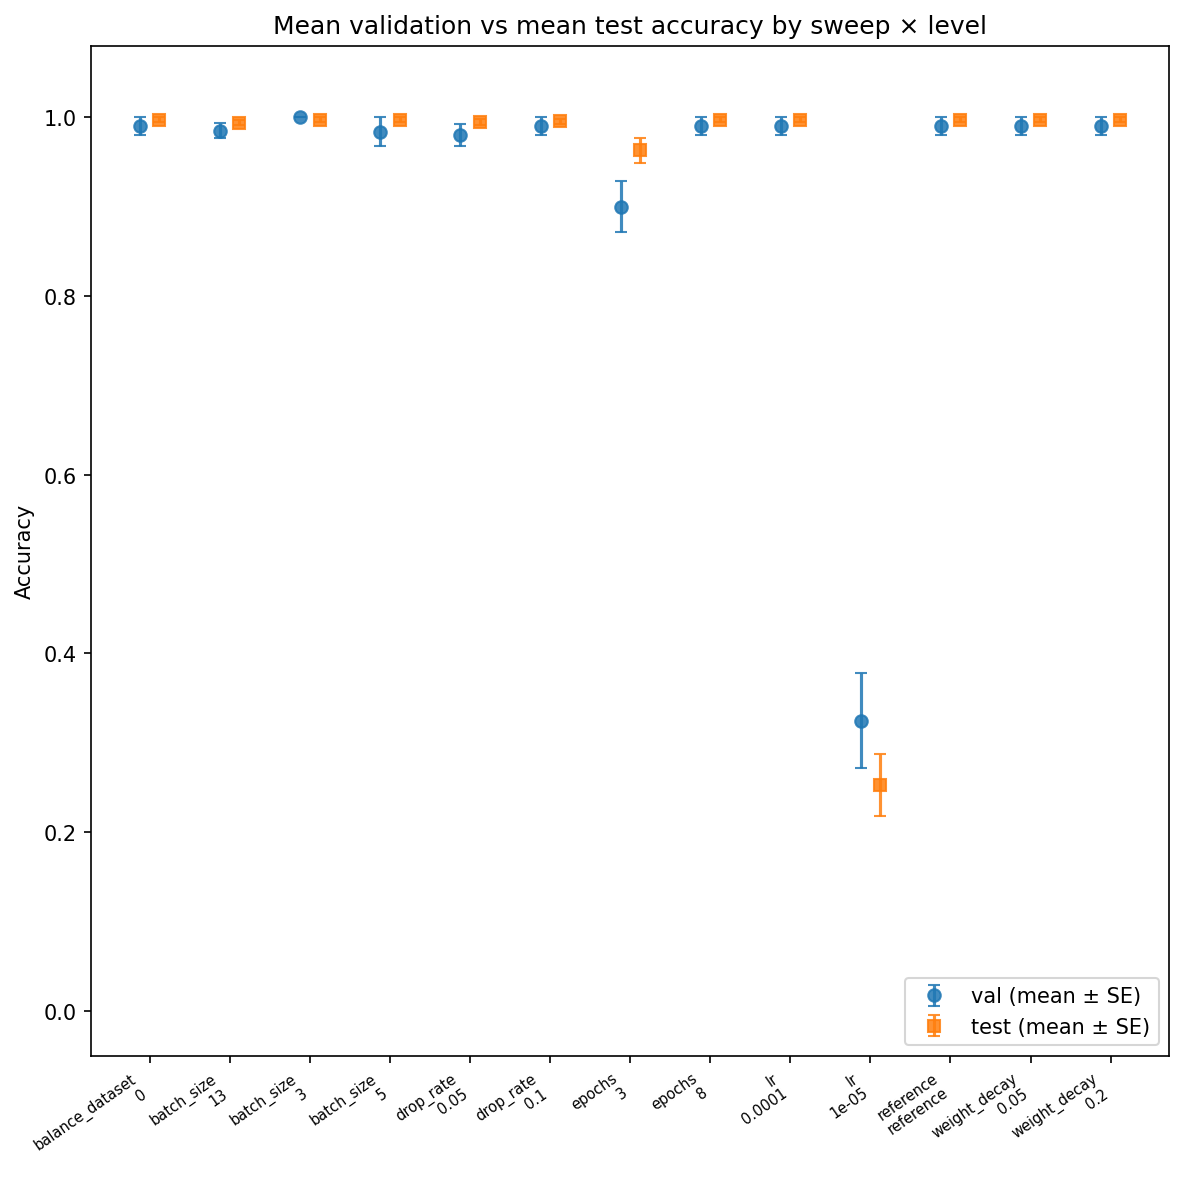

**`scatter_gap_vs_val_accuracy.png`**

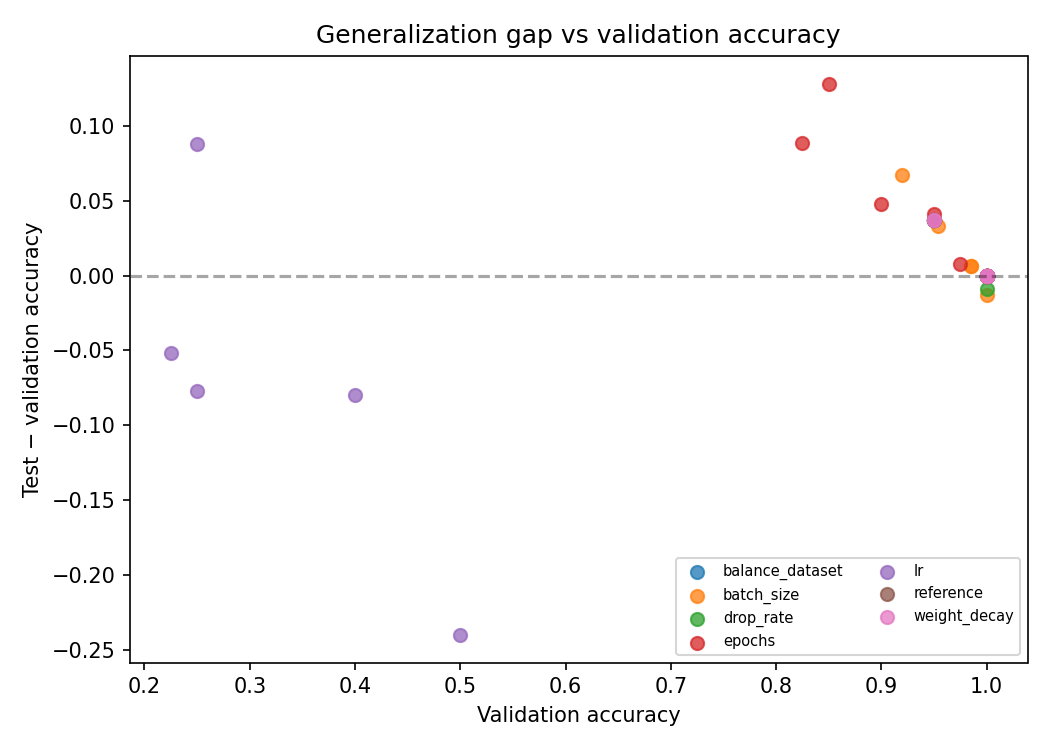

**`scatter_val_vs_test.png`**

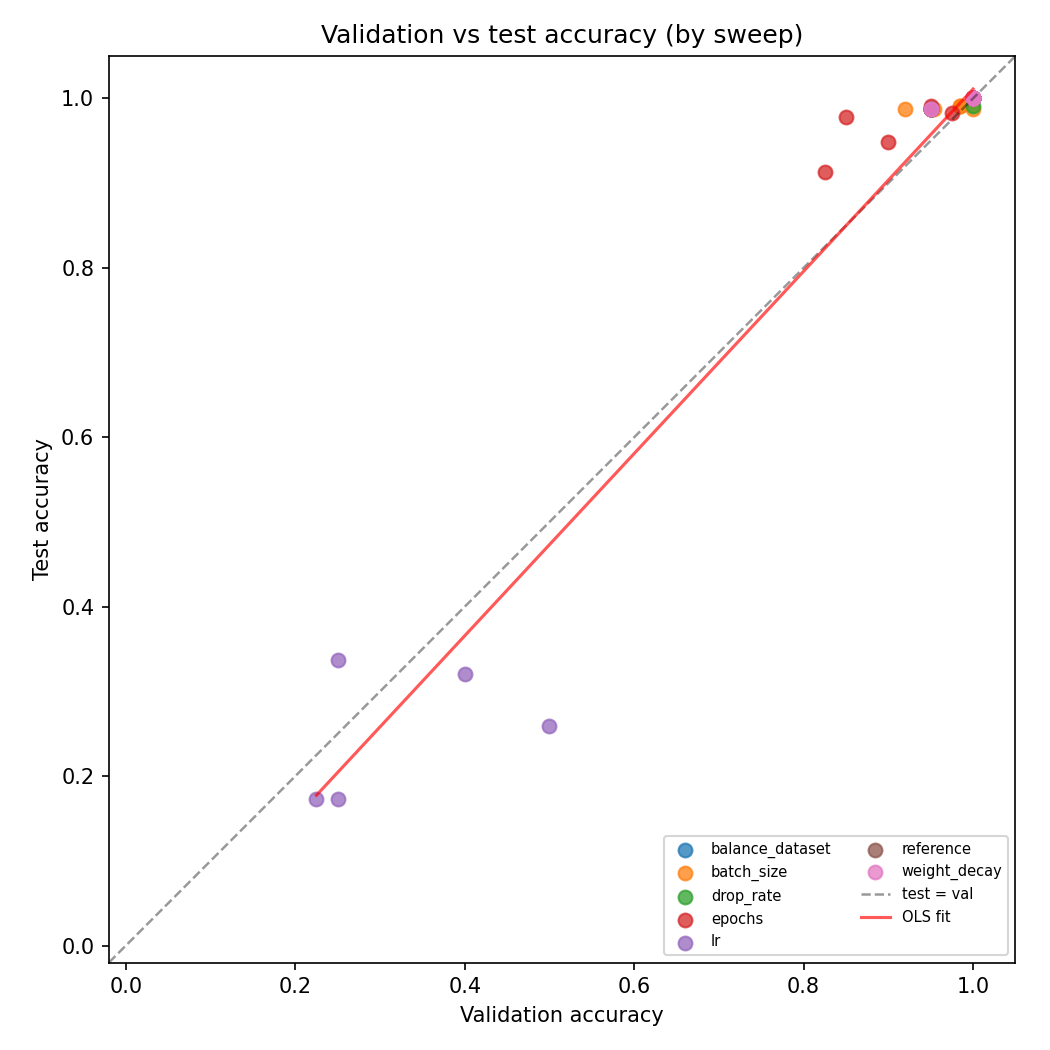

**`sweep_epochs__test_accuracy.png`**

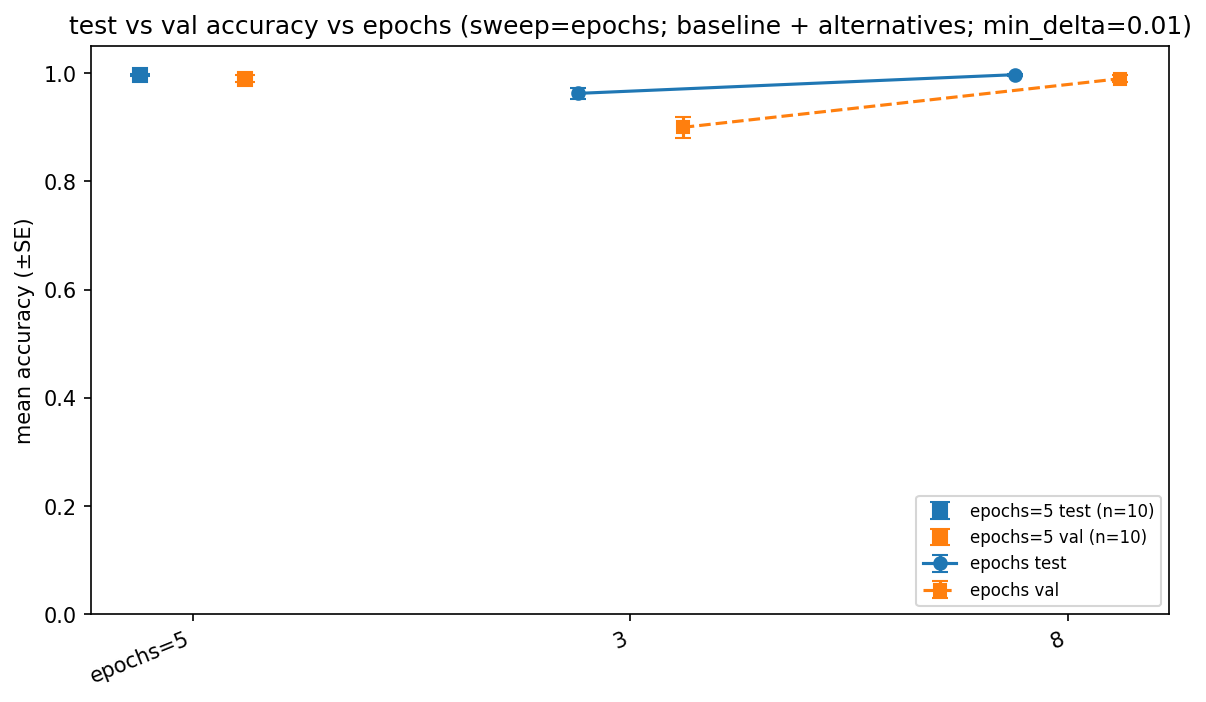

**`sweep_lr__test_accuracy.png`**

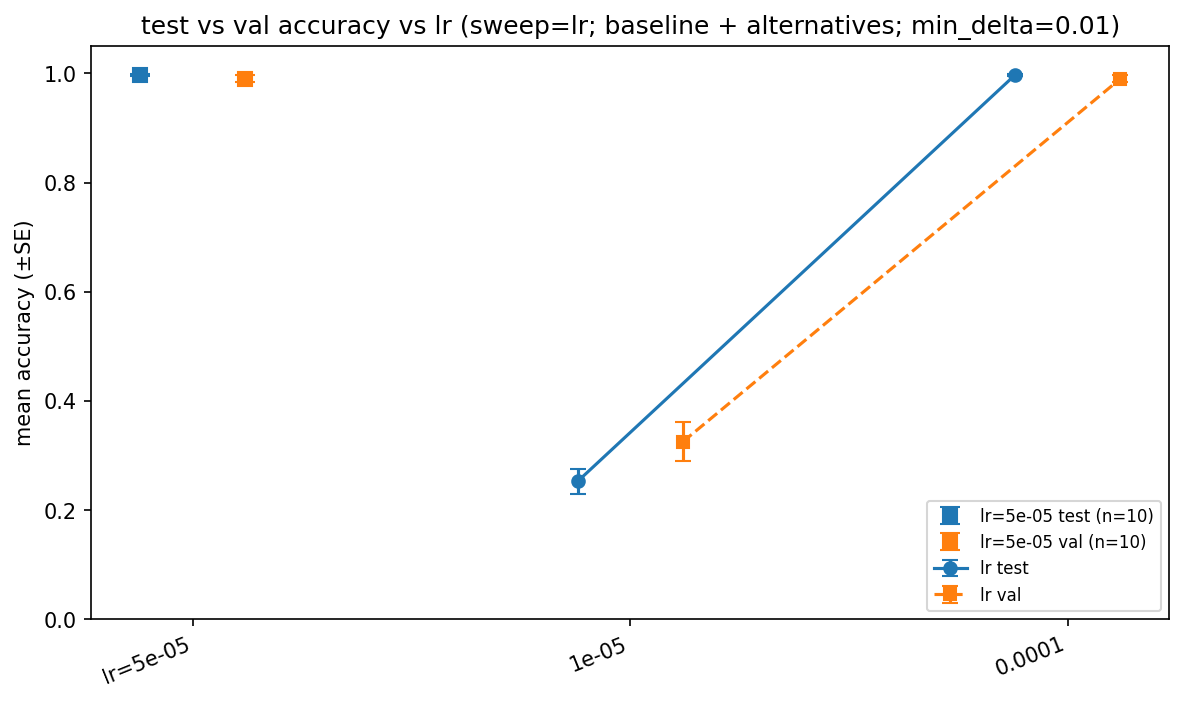

In [4]:
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

stats_dir = Path('stats_output')
summary_path = stats_dir / 'val_vs_test_by_sweep_level.csv'

if summary_path.is_file():
    summary = pd.read_csv(summary_path)
    display(Markdown('### Summary: `val_vs_test_by_sweep_level.csv`'))
    display(summary)
else:
    display(Markdown(f'_No `{summary_path}` yet — run `python run_stats.py` from this folder after filling `training-data.csv`._'))

tests_path = stats_dir / 'classical_tests.csv'
if tests_path.is_file():
    tests = pd.read_csv(tests_path)
    display(Markdown('### Classical tests (optional)'))
    display(tests.head(20))
    if len(tests) > 20:
        display(Markdown(f'_… {len(tests) - 20} more rows_'))

pngs = sorted(stats_dir.glob('*.png'))
if pngs:
    display(Markdown('### Figures'))
    for p in pngs:
        display(Markdown(f'**`{p.name}`**'))
        display(Image(filename=str(p)))
else:
    display(Markdown('_No PNGs in `stats_output/` — run `python run_stats.py` to generate plots._'))